# Kosambi–Karhunen–Loève Transform (KLT)

This notebook explores the **Kosambi–Karhunen–Loève theorem** from first principles. We will cover:

- Mathematical foundation: covariance eigendecomposition
- Why KLT is the optimal linear transform for energy compaction
- Estimating the KLT basis from an ensemble of realizations
- Decorrelation property: diagonal covariance in the transform domain
- Energy compaction comparison: KLT vs DCT
- Truncated reconstruction and compression
- 2D KLT on image patches
- Relation to Principal Component Analysis (PCA)

**Requirements:** `numpy`, `matplotlib`, `scipy`


In [24]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import dct
from scipy.ndimage import gaussian_filter
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['font.size'] = 10


## 1. Mathematical Foundation

Given a zero-mean discrete random process $\mathbf{x} \in \mathbb{R}^N$ with covariance matrix $\mathbf{C}_x = E[\mathbf{x}\mathbf{x}^T]$, the KLT seeks an orthonormal matrix $\mathbf{\Phi}$ such that the transformed coefficients $\mathbf{y} = \mathbf{\Phi}^T \mathbf{x}$ have a diagonal covariance matrix:

$$\mathbf{C}_y = \mathbf{\Phi}^T \mathbf{C}_x \mathbf{\Phi} = \text{diag}(\lambda_1, \lambda_2, \dots, \lambda_N)$$

The columns of $\mathbf{\Phi}$ are the **eigenvectors** of $\mathbf{C}_x$, and $\lambda_i$ are the corresponding **eigenvalues** sorted in descending order.

**Optimality:** Among all orthonormal transforms, the KLT maximizes energy compaction. For any $m < N$, retaining the first $m$ KLT coefficients minimizes the mean-square reconstruction error. This makes KLT the theoretical gold standard for transform coding.


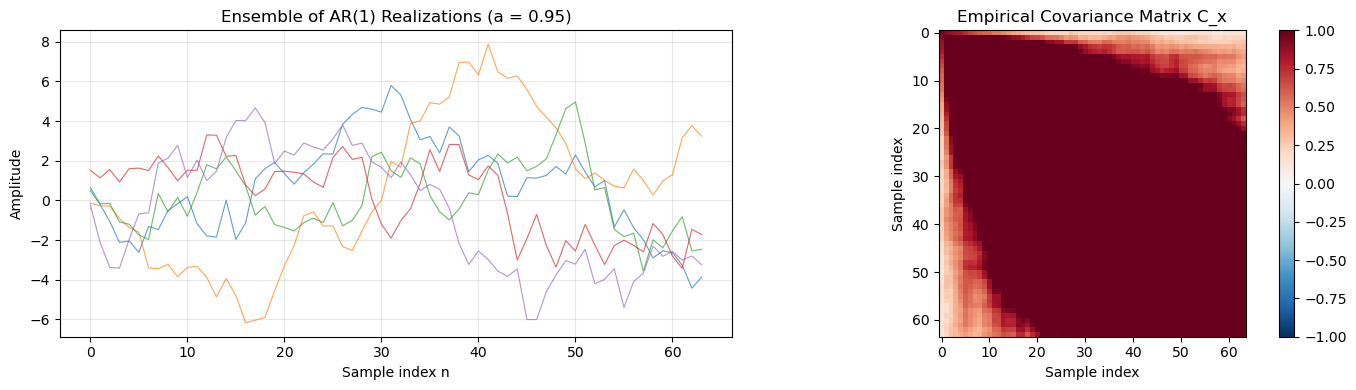

In [25]:
# Generate an ensemble of correlated signals (AR(1) process)
# x[n] = a * x[n-1] + w[n], where w[n] ~ N(0,1)
np.random.seed(42)
M = 2000      # Number of realizations (ensemble size)
N = 64        # Samples per realization
a = 0.95      # AR(1) coefficient (high correlation)

X = np.zeros((M, N))
X[:, 0] = np.random.randn(M)
for n in range(1, N):
    X[:, n] = a * X[:, n-1] + np.random.randn(M)

# Time vector for plotting
t = np.arange(N)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Plot a few realizations
for i in range(5):
    axes[0].plot(t, X[i, :], alpha=0.7, linewidth=0.8)
axes[0].set_title('Ensemble of AR(1) Realizations (a = {})'.format(a))
axes[0].set_xlabel('Sample index n')
axes[0].set_ylabel('Amplitude')
axes[0].grid(True, alpha=0.3)

# Plot the empirical covariance matrix
C_empirical = np.cov(X, rowvar=False, bias=True)
im = axes[1].imshow(C_empirical, cmap='RdBu_r', vmin=-1, vmax=1)
axes[1].set_title('Empirical Covariance Matrix C_x')
axes[1].set_xlabel('Sample index')
axes[1].set_ylabel('Sample index')
fig.colorbar(im, ax=axes[1])

plt.tight_layout()
plt.show()


## 2. Computing the KLT Basis

The KLT basis is obtained by performing an eigendecomposition of the covariance matrix. Because the covariance matrix is real and symmetric, we use `numpy.linalg.eigh` for numerical stability.

The eigenvectors (columns of $\mathbf{\Phi}$) form the KLT basis. The eigenvalues represent the variance captured by each basis vector. We sort them in descending order so that the first coefficient carries the most energy.


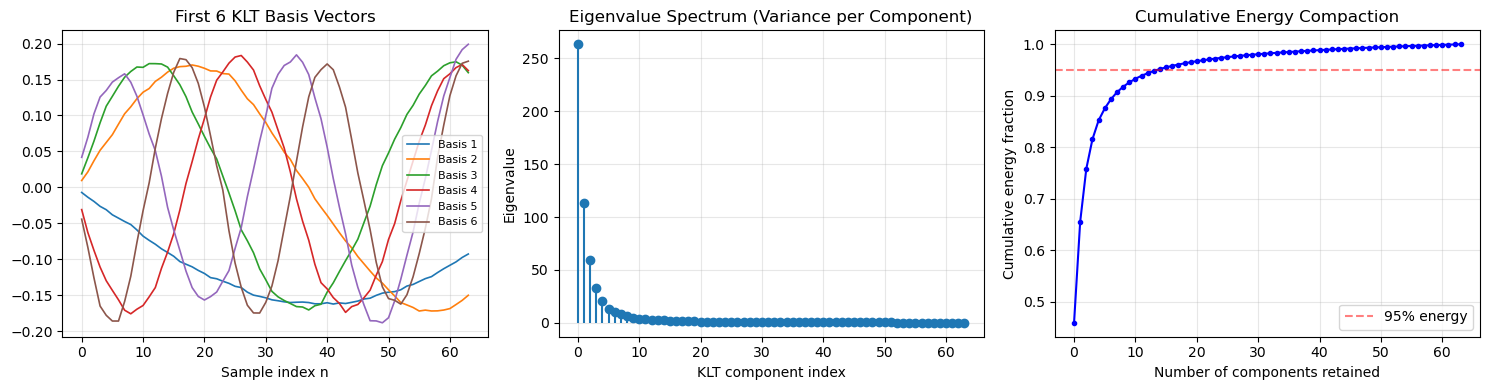

Top 5 eigenvalues: [263.29 112.79  59.03  32.86  20.93]
Components needed for 95% energy: 15


In [26]:
# Eigendecomposition of the covariance matrix
eigvals, eigvecs = np.linalg.eigh(C_empirical)

# Sort in descending order of eigenvalue
idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]

# KLT transform: Y = X * Phi (each row is a realization)
# Phi is the eigenvector matrix
Y = X @ eigvecs

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot first 6 KLT basis vectors
for i in range(6):
    axes[0].plot(t, eigvecs[:, i], label='Basis {}'.format(i+1), linewidth=1.2)
axes[0].set_title('First 6 KLT Basis Vectors')
axes[0].set_xlabel('Sample index n')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Eigenvalue spectrum
axes[1].stem(range(N), eigvals, basefmt=' ')
axes[1].set_title('Eigenvalue Spectrum (Variance per Component)')
axes[1].set_xlabel('KLT component index')
axes[1].set_ylabel('Eigenvalue')
axes[1].grid(True, alpha=0.3)

# Cumulative energy
cum_energy = np.cumsum(eigvals) / np.sum(eigvals)
axes[2].plot(cum_energy, 'b-o', markersize=3)
axes[2].axhline(0.95, color='r', linestyle='--', alpha=0.5, label='95% energy')
axes[2].set_title('Cumulative Energy Compaction')
axes[2].set_xlabel('Number of components retained')
axes[2].set_ylabel('Cumulative energy fraction')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Top 5 eigenvalues: {}".format(np.round(eigvals[:5], 2)))
print("Components needed for 95% energy: {}".format(np.argmax(cum_energy >= 0.95) + 1))


## 3. Decorrelation Property

The defining feature of the KLT is that the transformed coefficients are uncorrelated. The covariance matrix of $\mathbf{y}$ should be diagonal (the eigenvalue matrix). In practice, with finite samples, off-diagonal elements are small but not exactly zero.

We visualize the absolute covariance in the KLT domain to confirm the diagonal structure.


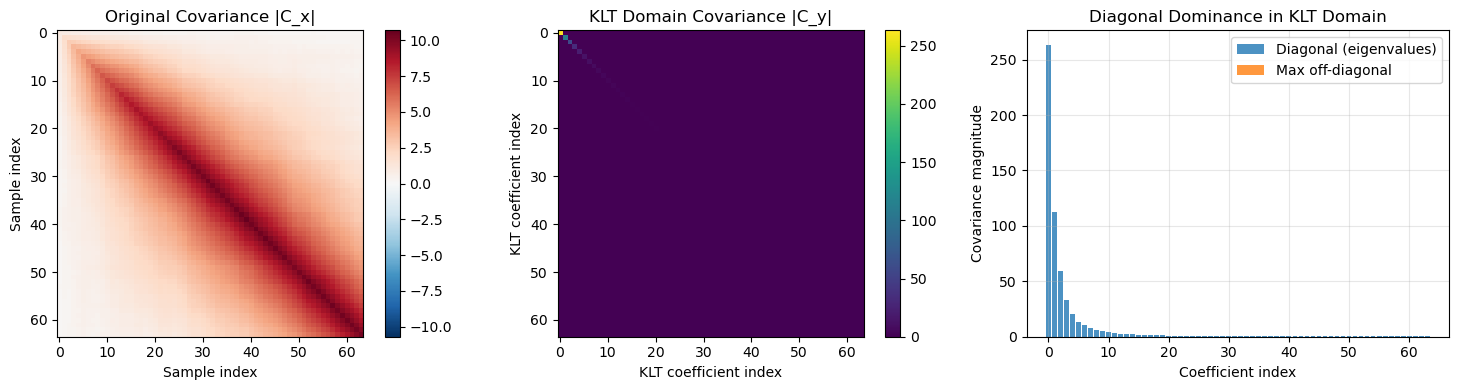

Max off-diagonal magnitude: 0.0000
Mean off-diagonal magnitude: 0.0000


In [27]:
# Covariance in the KLT domain
C_y = np.cov(Y, rowvar=False, bias=True)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Original covariance
vmax = np.max(np.abs(C_empirical))
im1 = axes[0].imshow(C_empirical, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
axes[0].set_title('Original Covariance |C_x|')
axes[0].set_xlabel('Sample index')
axes[0].set_ylabel('Sample index')
fig.colorbar(im1, ax=axes[0])

# KLT domain covariance (absolute value)
im2 = axes[1].imshow(np.abs(C_y), cmap='viridis')
axes[1].set_title('KLT Domain Covariance |C_y|')
axes[1].set_xlabel('KLT coefficient index')
axes[1].set_ylabel('KLT coefficient index')
fig.colorbar(im2, ax=axes[1])

# Diagonal vs max off-diagonal per row
diag_vals = np.diag(C_y)
off_diag = np.abs(C_y)
np.fill_diagonal(off_diag, 0)
max_off = np.max(off_diag, axis=1)

axes[2].bar(range(N), diag_vals, alpha=0.8, label='Diagonal (eigenvalues)')
axes[2].bar(range(N), max_off, alpha=0.8, label='Max off-diagonal')
axes[2].set_title('Diagonal Dominance in KLT Domain')
axes[2].set_xlabel('Coefficient index')
axes[2].set_ylabel('Covariance magnitude')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Max off-diagonal magnitude: {:.4f}".format(np.max(max_off)))
print("Mean off-diagonal magnitude: {:.4f}".format(np.mean(off_diag)))


## 4. Energy Compaction: KLT vs DCT

The KLT is data-dependent: the basis vectors must be computed from the covariance matrix. The **Discrete Cosine Transform (DCT)** is a fixed transform that approximates the KLT extremely well for Markov-1 processes with high correlation (which is why JPEG uses DCT).

We compare their energy compaction performance. For a fair comparison, we sort the coefficient variances of both transforms in descending order (showing the best possible compaction for each).


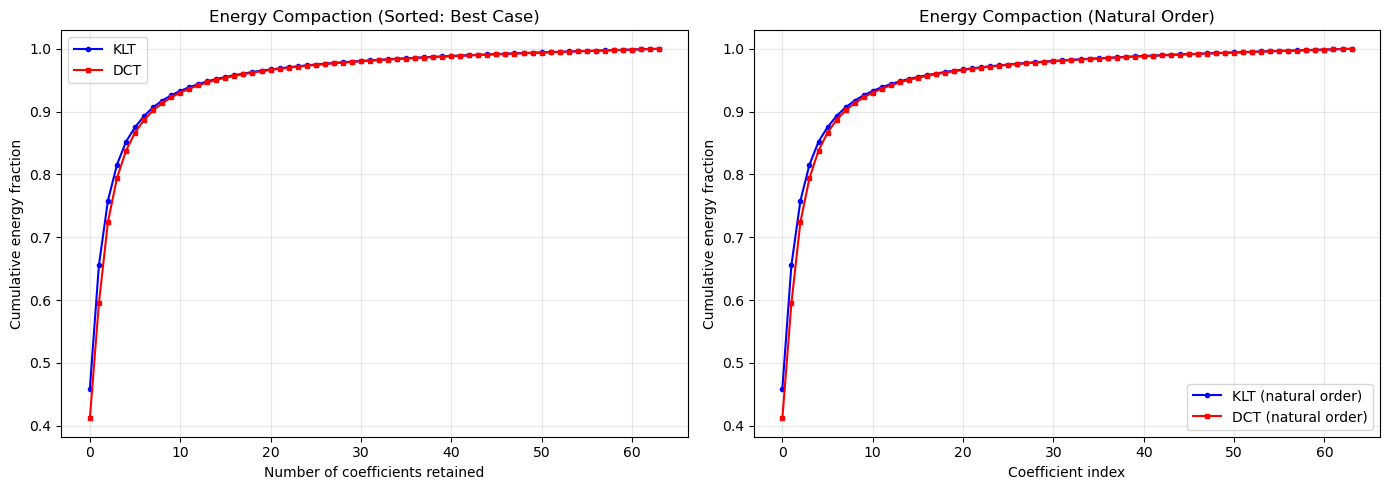

Energy retained with 8 coefficients:
  KLT (sorted):  0.907
  DCT (sorted):  0.902
  KLT (natural): 0.907
  DCT (natural): 0.902


In [28]:
# DCT (orthonormal type-II)
X_dct = dct(X, type=2, norm='ortho', axis=1)
var_dct = np.var(X_dct, axis=0)

# KLT variances are the eigenvalues
var_klt = eigvals

# Sorted cumulative energy (optimal ordering for each transform)
energy_klt = np.cumsum(np.sort(var_klt)[::-1]) / np.sum(var_klt)
energy_dct = np.cumsum(np.sort(var_dct)[::-1]) / np.sum(var_dct)

# Natural ordering (as they appear in the transform)
energy_klt_natural = np.cumsum(var_klt) / np.sum(var_klt)
energy_dct_natural = np.cumsum(var_dct) / np.sum(var_dct)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(energy_klt, 'b-o', markersize=3, label='KLT')
axes[0].plot(energy_dct, 'r-s', markersize=3, label='DCT')
axes[0].set_title('Energy Compaction (Sorted: Best Case)')
axes[0].set_xlabel('Number of coefficients retained')
axes[0].set_ylabel('Cumulative energy fraction')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(energy_klt_natural, 'b-o', markersize=3, label='KLT (natural order)')
axes[1].plot(energy_dct_natural, 'r-s', markersize=3, label='DCT (natural order)')
axes[1].set_title('Energy Compaction (Natural Order)')
axes[1].set_xlabel('Coefficient index')
axes[1].set_ylabel('Cumulative energy fraction')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Quantify the gap at 8 coefficients
k_test = 8
print("Energy retained with {} coefficients:".format(k_test))
print("  KLT (sorted):  {:.3f}".format(energy_klt[k_test-1]))
print("  DCT (sorted):  {:.3f}".format(energy_dct[k_test-1]))
print("  KLT (natural): {:.3f}".format(energy_klt_natural[k_test-1]))
print("  DCT (natural): {:.3f}".format(energy_dct_natural[k_test-1]))


## 5. Truncated Reconstruction and Compression

The KLT enables lossy compression: keep only the top $m$ coefficients (those with largest eigenvalues) and reconstruct. Because the KLT is orthonormal, reconstruction is simply a linear combination of the retained basis vectors.

The reconstruction MSE equals the sum of the discarded eigenvalues, proving that discarding the smallest eigenvalues is optimal.


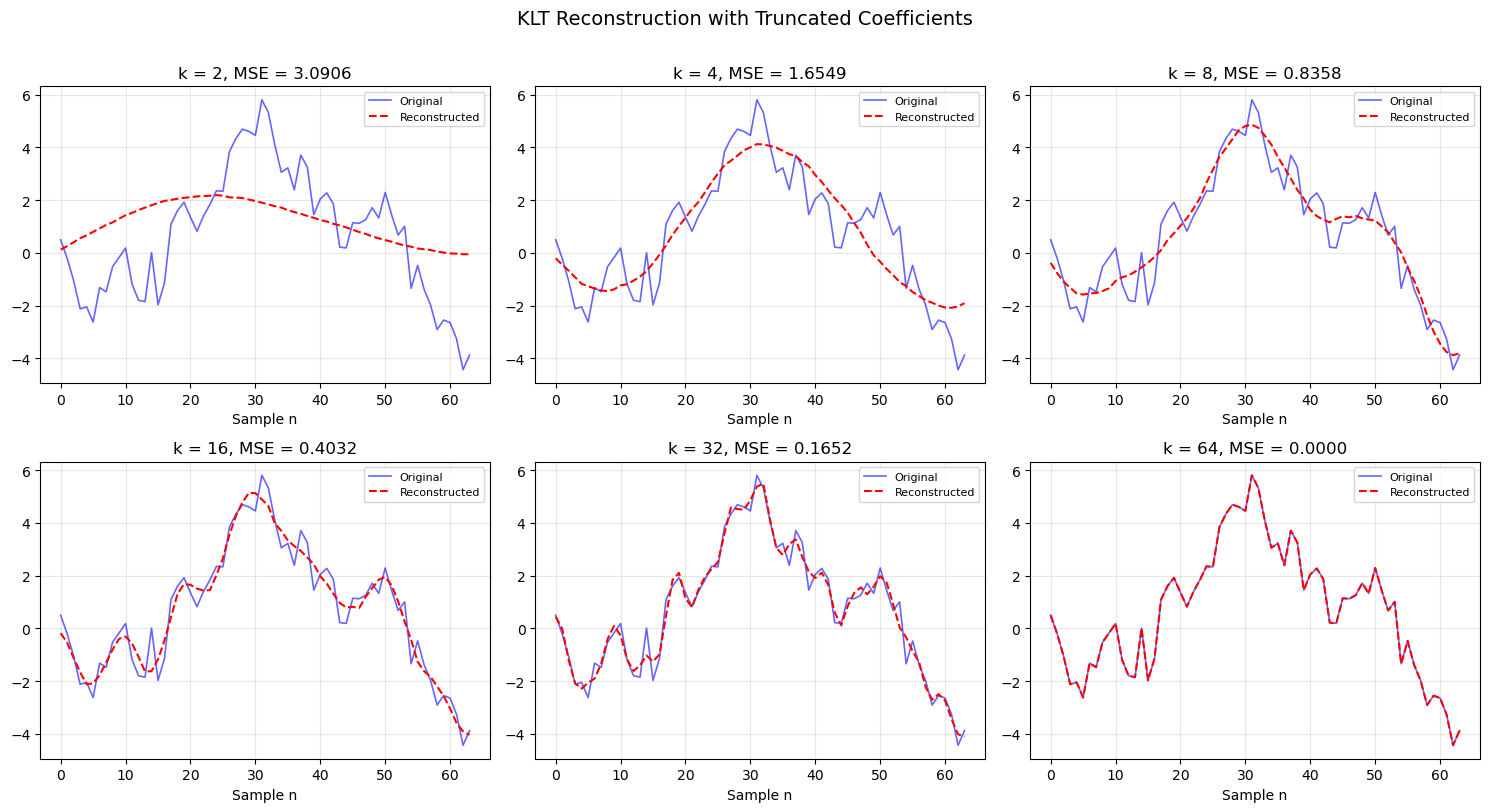

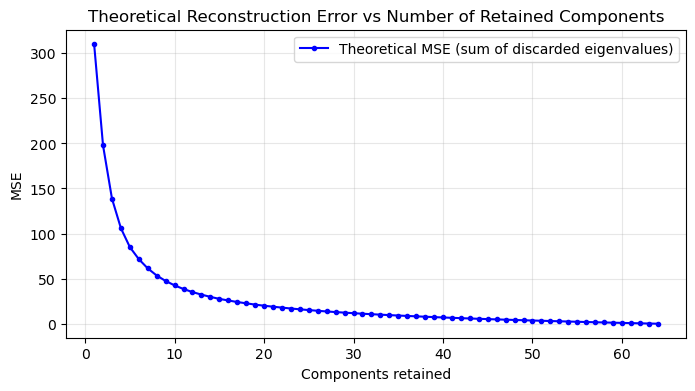

In [29]:
n_coeffs_list = [2, 4, 8, 16, 32, 64]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for idx, k in enumerate(n_coeffs_list):
    ax = axes[idx // 3, idx % 3]
    
    # Truncate coefficients
    Y_trunc = np.zeros_like(Y)
    Y_trunc[:, :k] = Y[:, :k]
    
    # Reconstruct: X_hat = Y_trunc * Phi^T
    X_recon = Y_trunc @ eigvecs.T
    
    # Plot one realization
    ax.plot(t, X[0, :], 'b-', alpha=0.6, linewidth=1.2, label='Original')
    ax.plot(t, X_recon[0, :], 'r--', linewidth=1.5, label='Reconstructed')
    
    # MSE over entire ensemble
    mse = np.mean((X - X_recon)**2)
    ax.set_title('k = {}, MSE = {:.4f}'.format(k, mse))
    ax.set_xlabel('Sample n')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('KLT Reconstruction with Truncated Coefficients', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Theoretical MSE vs empirical
theoretical_mse = np.zeros(N)
for m in range(1, N+1):
    theoretical_mse[m-1] = np.sum(eigvals[m:])

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, N+1), theoretical_mse, 'b-o', markersize=3, label='Theoretical MSE (sum of discarded eigenvalues)')
ax.set_title('Theoretical Reconstruction Error vs Number of Retained Components')
ax.set_xlabel('Components retained')
ax.set_ylabel('MSE')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()


## 6. 2D KLT on Image Patches

The KLT generalizes to 2D by vectorizing image patches and computing the covariance of the vectorized data. The resulting eigenvectors, when reshaped back to patch size, form **basis images** that are optimal for that image statistics.

This is the mathematical foundation behind PCA-based image compression and denoising.


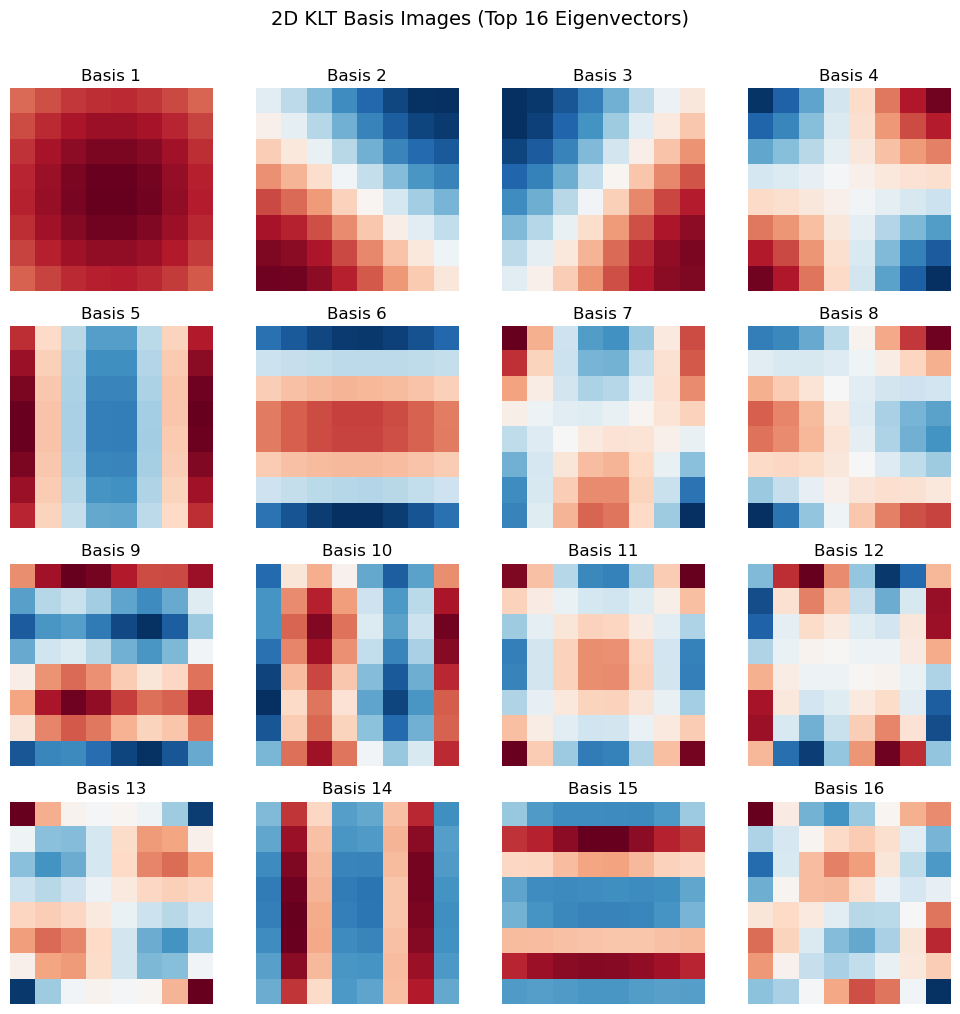

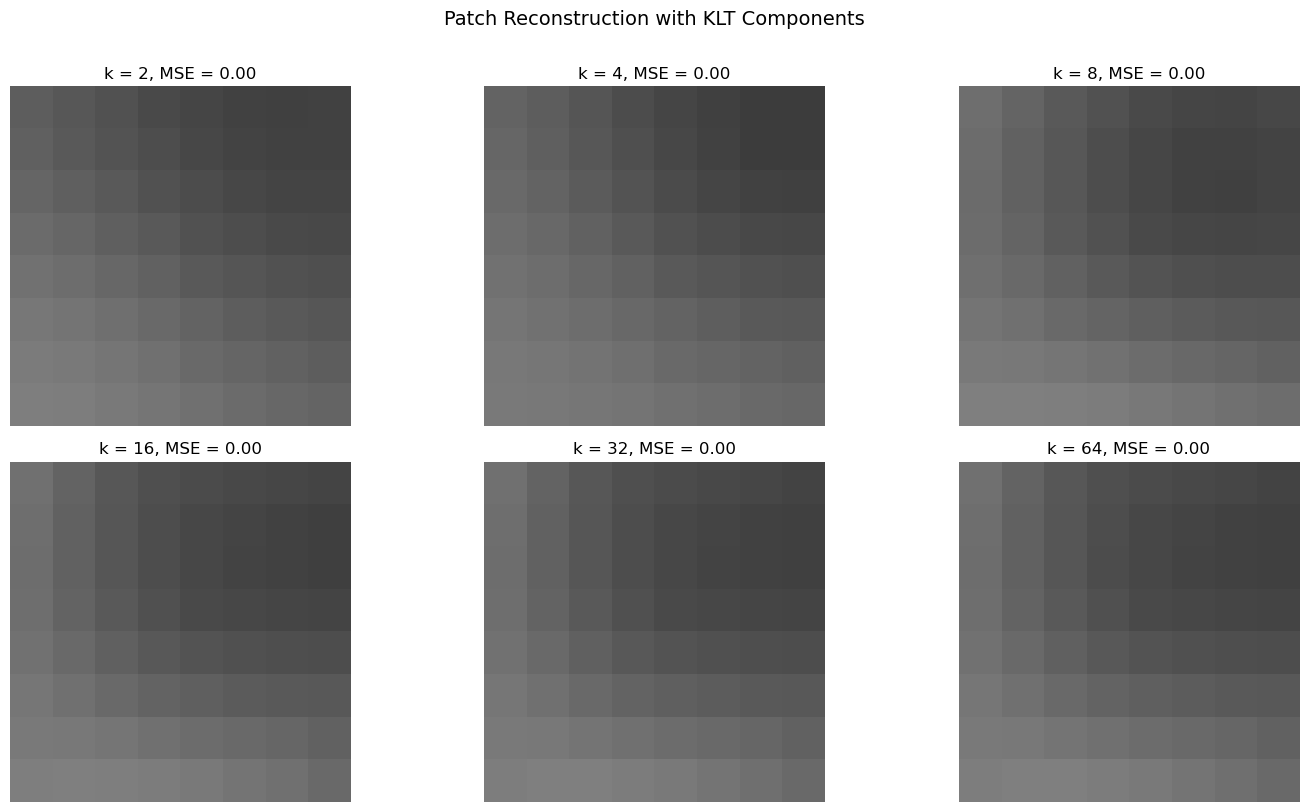

In [30]:
# Generate a smooth, correlated image
np.random.seed(0)
img_white = np.random.randn(256, 256)
img = gaussian_filter(img_white, sigma=3.0)

# Extract random 8x8 patches
patch_size = 8
n_patches = 6000
patches = np.zeros((n_patches, patch_size * patch_size))

for i in range(n_patches):
    row = np.random.randint(0, 256 - patch_size)
    col = np.random.randint(0, 256 - patch_size)
    patch = img[row:row+patch_size, col:col+patch_size].flatten()
    patches[i, :] = patch

# Center the patches
mean_patch = np.mean(patches, axis=0)
patches_centered = patches - mean_patch

# Compute patch covariance and KLT
C_patches = patches_centered.T @ patches_centered / n_patches
eigvals_p, eigvecs_p = np.linalg.eigh(C_patches)
idx_p = np.argsort(eigvals_p)[::-1]
eigvals_p = eigvals_p[idx_p]
eigvecs_p = eigvecs_p[:, idx_p]

# Display top 16 basis images
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for i in range(16):
    ax = axes[i // 4, i % 4]
    basis = eigvecs_p[:, i].reshape((patch_size, patch_size))
    vmax = np.max(np.abs(basis))
    ax.imshow(basis, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    ax.set_title('Basis {}'.format(i+1))
    ax.axis('off')

plt.suptitle('2D KLT Basis Images (Top 16 Eigenvectors)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Reconstruct a test patch with varying components
test_patch = patches_centered[0, :]
coeffs = test_patch @ eigvecs_p

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for idx, k in enumerate([2, 4, 8, 16, 32, 64]):
    ax = axes[idx // 3, idx % 3]
    c_trunc = np.zeros_like(coeffs)
    c_trunc[:k] = coeffs[:k]
    recon = c_trunc @ eigvecs_p.T + mean_patch
    
    ax.imshow(recon.reshape((patch_size, patch_size)), cmap='gray', 
              vmin=img.min(), vmax=img.max())
    mse = np.mean((patches[0, :] - recon)**2)
    ax.set_title('k = {}, MSE = {:.2f}'.format(k, mse))
    ax.axis('off')

plt.suptitle('Patch Reconstruction with KLT Components', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


## Summary

| Property | Description |
|----------|-------------|
| **Definition** | Eigendecomposition of the signal covariance matrix |
| **Optimality** | Minimizes MSE for any given number of retained coefficients |
| **Decorrelation** | Transformed coefficients have diagonal covariance |
| **Energy compaction** | Packs maximum variance into fewest coefficients |
| **Data-dependent** | Basis vectors must be estimated from data |
| **Relation to PCA** | KLT on an ensemble is identical to Principal Component Analysis |
| **DCT connection** | DCT approximates KLT for Markov-1 processes; used in JPEG |
| **Applications** | Lossy compression, feature extraction, denoising, face recognition (Eigenfaces) |

The KLT is the theoretical optimum for linear signal representation, but its computational cost (covariance estimation + eigendecomposition) and data-dependent nature make fixed transforms like DCT more practical for real-time standards. Understanding the KLT provides the benchmark against which all other transforms are measured.
